In [5]:
import pandas as pd

In [29]:
df = pd.read_csv("yfcc15m_geotagged_only.csv",nrows=5)
df

,photoid,uid,unickname,datetaken,dateuploaded,capturedevice,title,description,usertags,machinetags,...,pageurl,downloadurl,licensename,licenseurl,serverid,farmid,secret,secretoriginal,ext,marker
0,29060,34427466731@N01,striatic,2004-05-02 17:12:01.0,1083543121,NaN,Christmas+Panorama+%7Bnotes%7D,a+link+to+a+much+higher+resolution+version%2C+...,"alberta,canada,christmas,edmonton,family,indoo...",NaN,...,http://www.flickr.com/photos/34427466731@N01/2...,http://farm1.staticflickr.com/1/29060_e90c2a0c...,Attribution License,http://creativecommons.org/licenses/by/2.0/,1,1,e90c2a0c1c,e90c2a0c1c,jpg,0
1,29872,34427465504@N01,Trinity,2004-05-05 21:30:05.0,1083817805,NaN,bruise+5%2F2%2F4,I+got+this+bruise+at+work...wonder+if+I+can+ge...,"2004,bruise,me,photo,unfound",NaN,...,http://www.flickr.com/photos/34427465504@N01/2...,http://farm1.staticflickr.com/1/29872_c787b1b0...,Attribution-ShareAlike License,http://creativecommons.org/licenses/by-sa/2.0/,1,1,c787b1b056,c787b1b056,jpg,0
2,29873,34427465504@N01,Trinity,2004-05-05 21:30:06.0,1083817806,NaN,bruise+5%2F5%2F4,same+bruise%2C+day+4,"2004,bruise,me,photo,unfound",NaN,...,http://www.flickr.com/photos/34427465504@N01/2...,http://farm1.staticflickr.com/1/29873_d0359535...,Attribution-ShareAlike License,http://creativecommons.org/licenses/by-sa/2.0/,1,1,d0359535ab,d0359535ab,jpg,0
3,29874,34427465504@N01,Trinity,2004-05-05 21:30:07.0,1083817807,NaN,bruise+5%2F3%2F4,same+bruise%2C+day+2,"2004,bruise,me,photo,unfound",NaN,...,http://www.flickr.com/photos/34427465504@N01/2...,http://farm1.staticflickr.com/1/29874_f02c63c2...,Attribution-ShareAlike License,http://creativecommons.org/licenses/by-sa/2.0/,1,1,f02c63c2c8,f02c63c2c8,jpg,0
4,29875,34427465504@N01,Trinity,2004-05-05 21:30:09.0,1083817809,NaN,bruise+5%2F4%2F4,same+bruise%2C+day+3,"2004,bruise,me,photo,unfound",NaN,...,http://www.flickr.com/photos/34427465504@N01/2...,http://farm1.staticflickr.com/1/29875_6251beed...,Attribution-ShareAlike License,http://creativecommons.org/licenses/by-sa/2.0/,1,1,6251beed11,6251beed11,jpg,0


In [13]:
df.keys()

Index(['photoid', 'uid', 'unickname', 'datetaken', 'dateuploaded',
       'capturedevice', 'title', 'description', 'usertags', 'machinetags',
       'longitude', 'latitude', 'accuracy', 'pageurl', 'downloadurl',
       'licensename', 'licenseurl', 'serverid', 'farmid', 'secret',
       'secretoriginal', 'ext', 'marker'],
      dtype='object')

In [15]:
import pandas as pd
import requests
import os

input_file = "yfcc15m_geotagged_only.csv"
output_folder = "test_images"

os.makedirs(output_folder, exist_ok=True)

# Read only first 10 rows
df = pd.read_csv(input_file, usecols=["downloadurl"], nrows=10)

for i, url in enumerate(df["downloadurl"].dropna()):
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()

        filename = os.path.join(output_folder, f"image_{i}.jpg")

        with open(filename, "wb") as f:
            f.write(response.content)

        print(f"Downloaded {i+1}")

    except Exception as e:
        print("Failed:", url)

print("Test complete.")

Downloaded 1
Downloaded 2
Downloaded 3
Downloaded 4
Downloaded 5
Downloaded 6
Downloaded 7
Downloaded 8
Downloaded 9
Downloaded 10
Test complete.


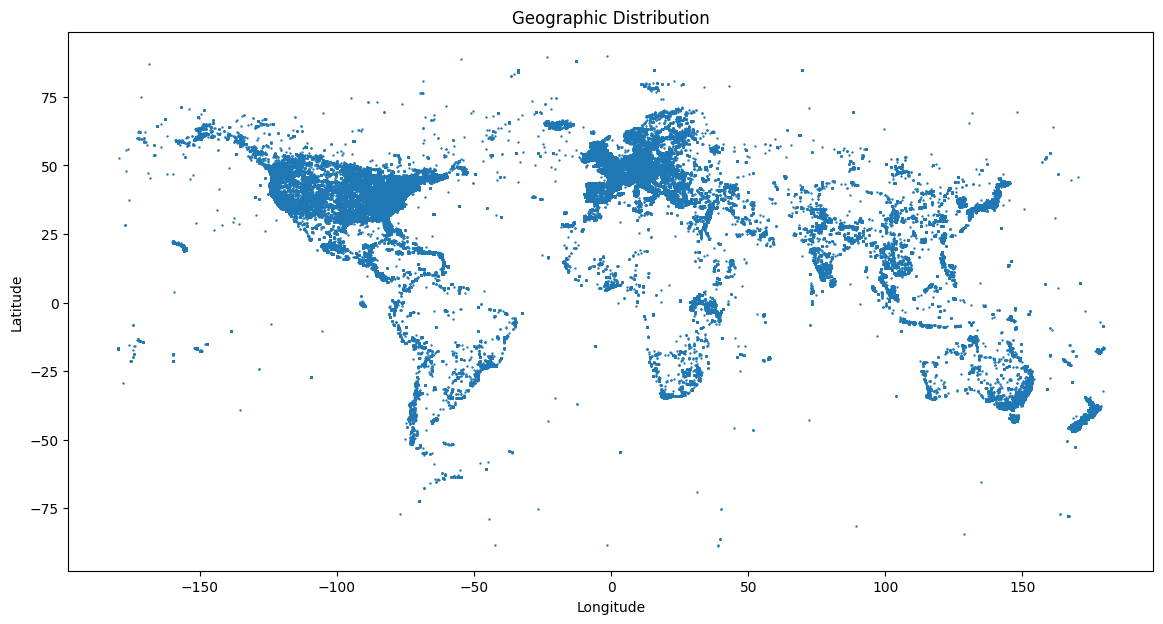

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

input_file = "yfcc15m_geotagged_only.csv"

df = pd.read_csv(
    input_file,
    usecols=["latitude", "longitude"],
    nrows=1000000
)
plt.figure(figsize = (14,7))
plt.scatter(df["longitude"], df["latitude"], s=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution")
plt.show()


In [24]:
# Europe bounds
europe_bounds = {
    "lat_min": 35.0,
    "lat_max": 72.0,
    "lon_min": -10.0,
    "lon_max": 40.0
}

In [25]:
# USA bounds
usa_bounds = {
    "lat_min": 24.0,
    "lat_max": 49.5,
    "lon_min": -125.0,
    "lon_max": -66.5
}

In [26]:
import pandas as pd

input_file = "yfcc15m_geotagged_only.csv"
output_file = "usa_europe_full_columns.csv"

chunksize = 500_000
first_chunk = True



for chunk in pd.read_csv(input_file, chunksize=chunksize):

    chunk = chunk.dropna(subset=["latitude", "longitude"])

    usa = chunk[
        (chunk["latitude"] >= usa_bounds["lat_min"]) &
        (chunk["latitude"] <= usa_bounds["lat_max"]) &
        (chunk["longitude"] >= usa_bounds["lon_min"]) &
        (chunk["longitude"] <= usa_bounds["lon_max"])
    ]

    europe = chunk[
        (chunk["latitude"] >= europe_bounds["lat_min"]) &
        (chunk["latitude"] <= europe_bounds["lat_max"]) &
        (chunk["longitude"] >= europe_bounds["lon_min"]) &
        (chunk["longitude"] <= europe_bounds["lon_max"])
    ]

    result = pd.concat([usa, europe])

    if not result.empty:
        result.to_csv(
            output_file,
            mode="w" if first_chunk else "a",
            header=first_chunk,
            index=False
        )
        first_chunk = False

print("Final dataset created with all columns.")

Final dataset created with all columns.


In [33]:
df = pd.read_csv("usa_europe_geotagged.csv", nrows = 10);
df

,photoid,uid,unickname,datetaken,dateuploaded,capturedevice,title,description,usertags,machinetags,...,pageurl,downloadurl,licensename,licenseurl,serverid,farmid,secret,secretoriginal,ext,marker
0,29872,34427465504@N01,Trinity,2004-05-05 21:30:05.0,1083817805,NaN,bruise+5%2F2%2F4,I+got+this+bruise+at+work...wonder+if+I+can+ge...,"2004,bruise,me,photo,unfound",NaN,...,http://www.flickr.com/photos/34427465504@N01/2...,http://farm1.staticflickr.com/1/29872_c787b1b0...,Attribution-ShareAlike License,http://creativecommons.org/licenses/by-sa/2.0/,1,1,c787b1b056,c787b1b056,jpg,0
1,29873,34427465504@N01,Trinity,2004-05-05 21:30:06.0,1083817806,NaN,bruise+5%2F5%2F4,same+bruise%2C+day+4,"2004,bruise,me,photo,unfound",NaN,...,http://www.flickr.com/photos/34427465504@N01/2...,http://farm1.staticflickr.com/1/29873_d0359535...,Attribution-ShareAlike License,http://creativecommons.org/licenses/by-sa/2.0/,1,1,d0359535ab,d0359535ab,jpg,0
2,29874,34427465504@N01,Trinity,2004-05-05 21:30:07.0,1083817807,NaN,bruise+5%2F3%2F4,same+bruise%2C+day+2,"2004,bruise,me,photo,unfound",NaN,...,http://www.flickr.com/photos/34427465504@N01/2...,http://farm1.staticflickr.com/1/29874_f02c63c2...,Attribution-ShareAlike License,http://creativecommons.org/licenses/by-sa/2.0/,1,1,f02c63c2c8,f02c63c2c8,jpg,0
3,29875,34427465504@N01,Trinity,2004-05-05 21:30:09.0,1083817809,NaN,bruise+5%2F4%2F4,same+bruise%2C+day+3,"2004,bruise,me,photo,unfound",NaN,...,http://www.flickr.com/photos/34427465504@N01/2...,http://farm1.staticflickr.com/1/29875_6251beed...,Attribution-ShareAlike License,http://creativecommons.org/licenses/by-sa/2.0/,1,1,6251beed11,6251beed11,jpg,0
4,30431,34427469121@N01,George,2004-03-05 15:03:52.0,1083960838,FUJIFILM+FinePix+S5000,Space+age,This+is+the+little+lift+which+goes+up+the+Spac...,"elevator,seattle,space+needle,space+travel",NaN,...,http://www.flickr.com/photos/34427469121@N01/3...,http://farm1.staticflickr.com/1/30431_37ed41d3...,Attribution-NonCommercial-NoDerivs License,http://creativecommons.org/licenses/by-nc-nd/2.0/,1,1,37ed41d3fb,37ed41d3fb,jpg,0
5,30872,34427466731@N01,striatic,2004-05-08 23:56:42.0,1084085802,NaN,vancouver+panorama+thumbnail,yes+..+this+photo+is+unreasonably+small+%7E+so...,"bc,british+columbia,canada,landscape,my+%27goo...",NaN,...,http://www.flickr.com/photos/34427466731@N01/3...,http://farm1.staticflickr.com/1/30872_7b9963df...,Attribution License,http://creativecommons.org/licenses/by/2.0/,1,1,7b9963df98,7b9963df98,jpg,0
6,33811,34427466731@N01,striatic,2004-04-24 12:16:29.0,1084570173,Canon+PowerShot+A40,Toronto+..+you+can+see+my+house+from+here%21+%...,%3Ca+href%3D%22http%3A%2F%2Fflickr.com%2Fphoto...,"landscape,neill+wycik,notes,outdoor,photo,snag...",NaN,...,http://www.flickr.com/photos/34427466731@N01/3...,http://farm1.staticflickr.com/1/33811_aa287840...,Attribution License,http://creativecommons.org/licenses/by/2.0/,1,1,aa28784040,aa28784040,jpg,0
7,37034,34427466731@N01,striatic,2004-05-22 07:44:00.0,1085400628,NIKON+E950,PORTAL+%7E+NEILL+WYCIK+%7Bnotes%7D,%3Cb%3EPORTAL%3C%2Fb%3E%3A+NEILL+WYCIK+%7E+whe...,"canada,cityproject,coop,glowproject,landscape,...",NaN,...,http://www.flickr.com/photos/34427466731@N01/3...,http://farm1.staticflickr.com/1/37034_09fbb1fb...,Attribution License,http://creativecommons.org/licenses/by/2.0/,1,1,09fbb1fbd1,09fbb1fbd1,jpg,0
8,37097,34427469121@N01,George,2004-05-23 19:02:37.0,1085419289,FUJIFILM+FinePix+S5000,Post+no+bills,A+local+artistic+person+painted+a+quaint+littl...,"duck,graffiti,post+no+bills,vancouver",NaN,...,http://www.flickr.com/photos/34427469121@N01/3...,http://farm1.staticflickr.com/1/37097_b2ba748a...,Attribution-NonCommercial-NoDerivs License,http://creativecommons.org/licenses/by-nc-nd/2.0/,1,1,b2ba748acb,b2ba748acb,jpg,0
9,39961,34427465504@N01,Trinity,2004-05-31 20:06:38.0,1086059198,NaN,My+Flickr+contacts+%28with+notes%29,My+contacts+as+of+May+31%2C+2004.++More+notes+...,"2004,contact,friend,unfound",NaN,...,http://www.flickr.com/photos/34427465504@N01/

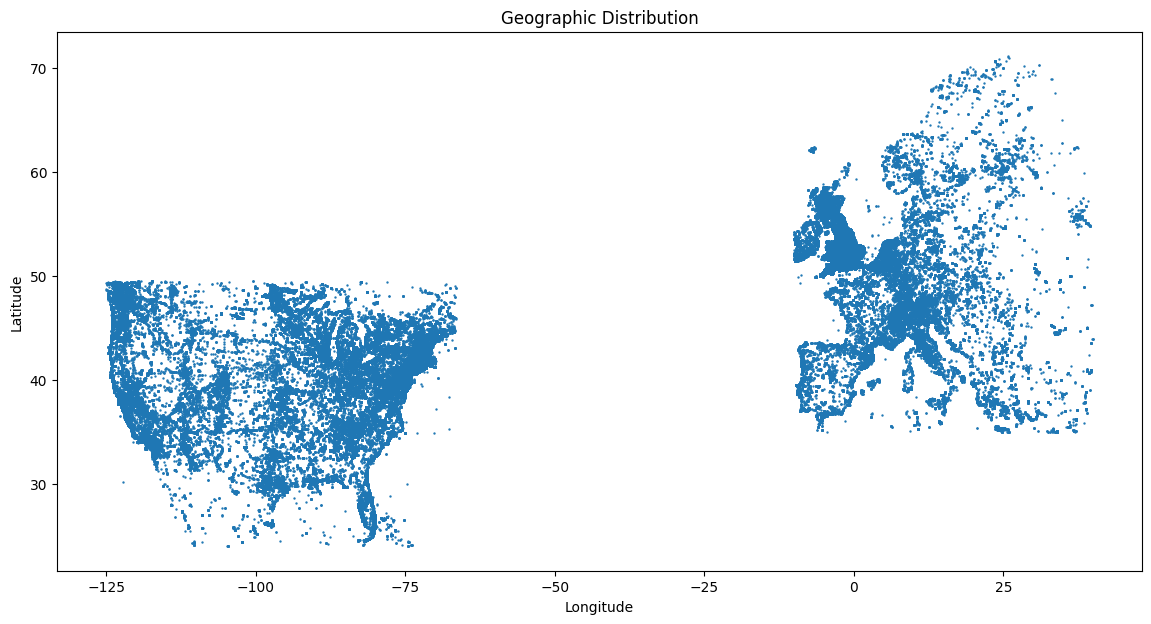

In [35]:
input_file = "usa_europe_geotagged.csv"

df = pd.read_csv(
    input_file,
    usecols=["latitude", "longitude"],
    nrows=1000000
)
plt.figure(figsize = (14,7))
plt.scatter(df["longitude"], df["latitude"], s=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution")
plt.show()